# WP5 — IMF normalization and completeness

This notebook is the explanatory, read-only view of the executed WP5 pipeline.
It consumes only named WP5 artifacts.  It does not refit or overwrite upstream
WP2–WP4 products.

The intended downstream quantity is the birth-population normalization
\(k\) per subgroup.  The validation result is blocking: no absolute 95%
end-to-end completeness edge exists, and the response-aware IMF residuals are
not consistent with Poisson scatter.  The notebook therefore ends with a
blocked handoff rather than an accepted normalization.

## 1. Load the named artifacts and verify their shapes

Purpose: confirm that every mandatory family, extinction-law, slope, and
subgroup branch exists before interpreting any result.  Expected dimensions
are fixed by the registered grid: 2 families × 3 R_V values × 3 subgroups,
with 3 IMF slopes added for the normalization.

Downstream effect: a missing branch would invalidate the sensitivity envelope
and stop this notebook immediately.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path(".").resolve()
PROC = ROOT / "data" / "processed"

curves = pd.read_parquet(PROC / "wp5_completeness_curves.parquet")
response = pd.read_parquet(PROC / "wp5_injection_response.parquet")
normalization = pd.read_parquet(PROC / "wp5_imf_normalization.parquet")
mass_bins = pd.read_parquet(PROC / "wp5_mass_function_bins.parquet")
association = pd.read_parquet(PROC / "wp5_association_mass.parquet")

expected = {
    "completeness_rows": 2 * 3 * 3 * 31,
    "response_rows": 2 * 3 * 3 * 31 * 400,
    "normalization_rows": 2 * 3 * 3 * 3,
    "mass_bin_rows": 2 * 3 * 3 * 3 * 6,
    "association_rows": 2 * 3 * 3,
}
actual = {
    "completeness_rows": len(curves),
    "response_rows": len(response),
    "normalization_rows": len(normalization),
    "mass_bin_rows": len(mass_bins),
    "association_rows": len(association),
}
assert actual == expected, (actual, expected)
pd.DataFrame({"expected": expected, "actual": actual})

,expected,actual
completeness_rows,558,558
response_rows,223200,223200
normalization_rows,54,54
mass_bin_rows,324,324
association_rows,18,18


## 2. Inspect the end-to-end completeness curve

Purpose: distinguish Gaia-query visibility from the full chain.  A star can be
brighter than G=19 yet fail the astrometric-quality domain, the WP2
cluster-versus-field classifier, or the photometry needed for a WP4 mass.

Threshold: the execution plan requires the lower calibration edge to be at
least 95% complete.  The vertical dotted line marks the nominal 2 M_sun edge;
the horizontal dashed line is the absolute 95% requirement.

Limitation: this is a catalogue-level injection using real Gaia observational
states.  Gaia epoch images and AGIS cannot be rerun, so it is not an
image-level artificial-source test.

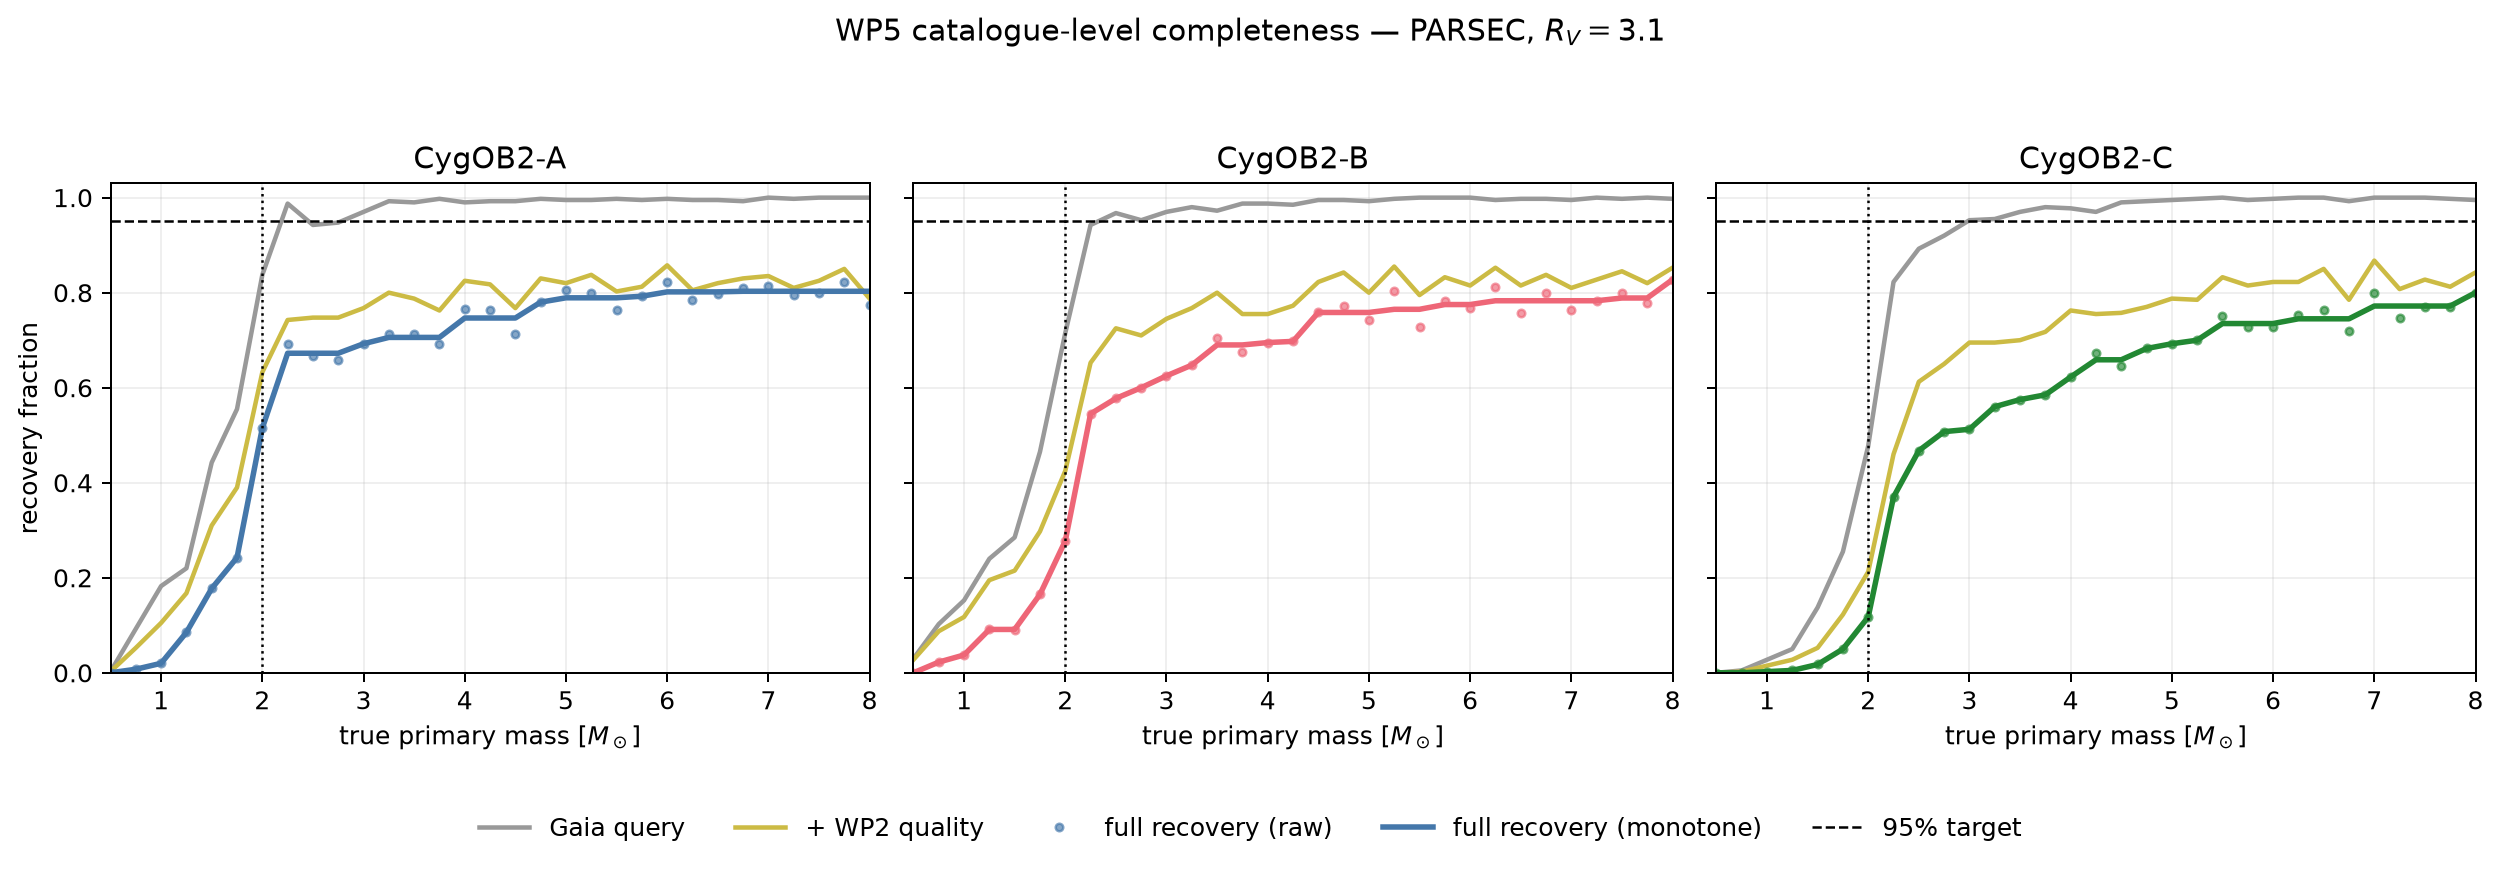

,subgroup,full_recovery_at_2_Msun,median_full_recovery_6_8_Msun,maximum_monotone_recovery_above_2
0,CygOB2-A,0.5150,0.8000,0.802917
1,CygOB2-B,0.2775,0.7825,0.827500
2,CygOB2-C,0.1175,0.7625,0.800000


In [2]:
display(Image(filename=str(ROOT / "figures" / "wp5" / "wp5_completeness_curves.png")))

baseline_curve = curves[(curves.family == "PARSEC") & (curves.R_V == 3.1)]
summary = []
for subgroup, group in baseline_curve.groupby("subgroup"):
    at_two = group.loc[group.primary_mass.eq(2.0)].iloc[0]
    summary.append({
        "subgroup": subgroup,
        "full_recovery_at_2_Msun": at_two.recovery_fraction,
        "median_full_recovery_6_8_Msun":
            group.loc[group.primary_mass.between(6, 8), "recovery_fraction"].median(),
        "maximum_monotone_recovery_above_2":
            group.loc[group.primary_mass.ge(2), "recovery_isotonic"].max(),
    })
pd.DataFrame(summary)

## 3. Freeze the calibration-window verdict

Purpose: prevent a relative bright-plateau threshold from being silently
reported as absolute completeness.  `absolute_95_edge_Msun` must be finite to
pass the planned criterion.

Result: no subgroup/family/R_V branch has an absolute 95% edge.  The
`corrected_no_absolute95_edge` fit is retained only as a diagnostic because the
measured response can correct incomplete bins; it does not satisfy the original
window requirement.

In [3]:
edge_audit = normalization[
    ["subgroup", "family", "R_V", "absolute_95_edge_Msun",
     "relative_95_plateau_edge_Msun_diagnostic",
     "bright_plateau_completeness", "window_status"]
].drop_duplicates()
assert edge_audit.absolute_95_edge_Msun.isna().all()
edge_audit.head(18)

,subgroup,family,R_V,absolute_95_edge_Msun,relative_95_plateau_edge_Msun_diagnostic,bright_plateau_completeness,window_status
0,CygOB2-A,PARSEC,3.0,NaN,4.50,0.805556,corrected_no_absolute95_edge
1,CygOB2-B,PARSEC,3.0,NaN,4.25,0.767500,corrected_no_absolute95_edge
2,CygOB2-C,PARSEC,3.0,NaN,6.00,0.766500,corrected_no_absolute95_edge
9,CygOB2-A,PARSEC,3.1,NaN,4.75,0.802917,corrected_no_absolute95_edge
10,CygOB2-B,PARSEC,3.1,NaN,4.50,0.783000,corrected_no_absolute95_edge
11,CygOB2-C,PARSEC,3.1,NaN,5.50,0.771875,corrected_no_absolute95_edge
18,CygOB2-A,PARSEC,3.5,NaN,5.75,0.820000,corrected_no_absolute95_edge
19,CygOB2-B,PARSEC,3.5,NaN,5.25,0.776875,corrected_no_absolute95_edge
20,CygOB2-C,PARSEC,3.5,NaN,5.50,0.759583,corrected_no_absolute95_edge
27,CygOB2-A,MIST,3.0,NaN,4.00,0.795833,corrected_no_absolute95_edge


## 4. Inspect the response-aware Poisson IMF fit

Purpose: compare the membership-weighted observed counts with a forward model
that includes selection, binary brightening, extinction/photometric errors, and
migration through the exact WP4 nearest-isochrone mass estimator.

Gate: Pearson residuals must be compatible with Poisson scatter, with no
systematic bin behavior.  The shaded ±3 region is a visual diagnostic; the
registered numerical gate also requires chi-square p>=0.01 and no significant
monotonic residual trend.

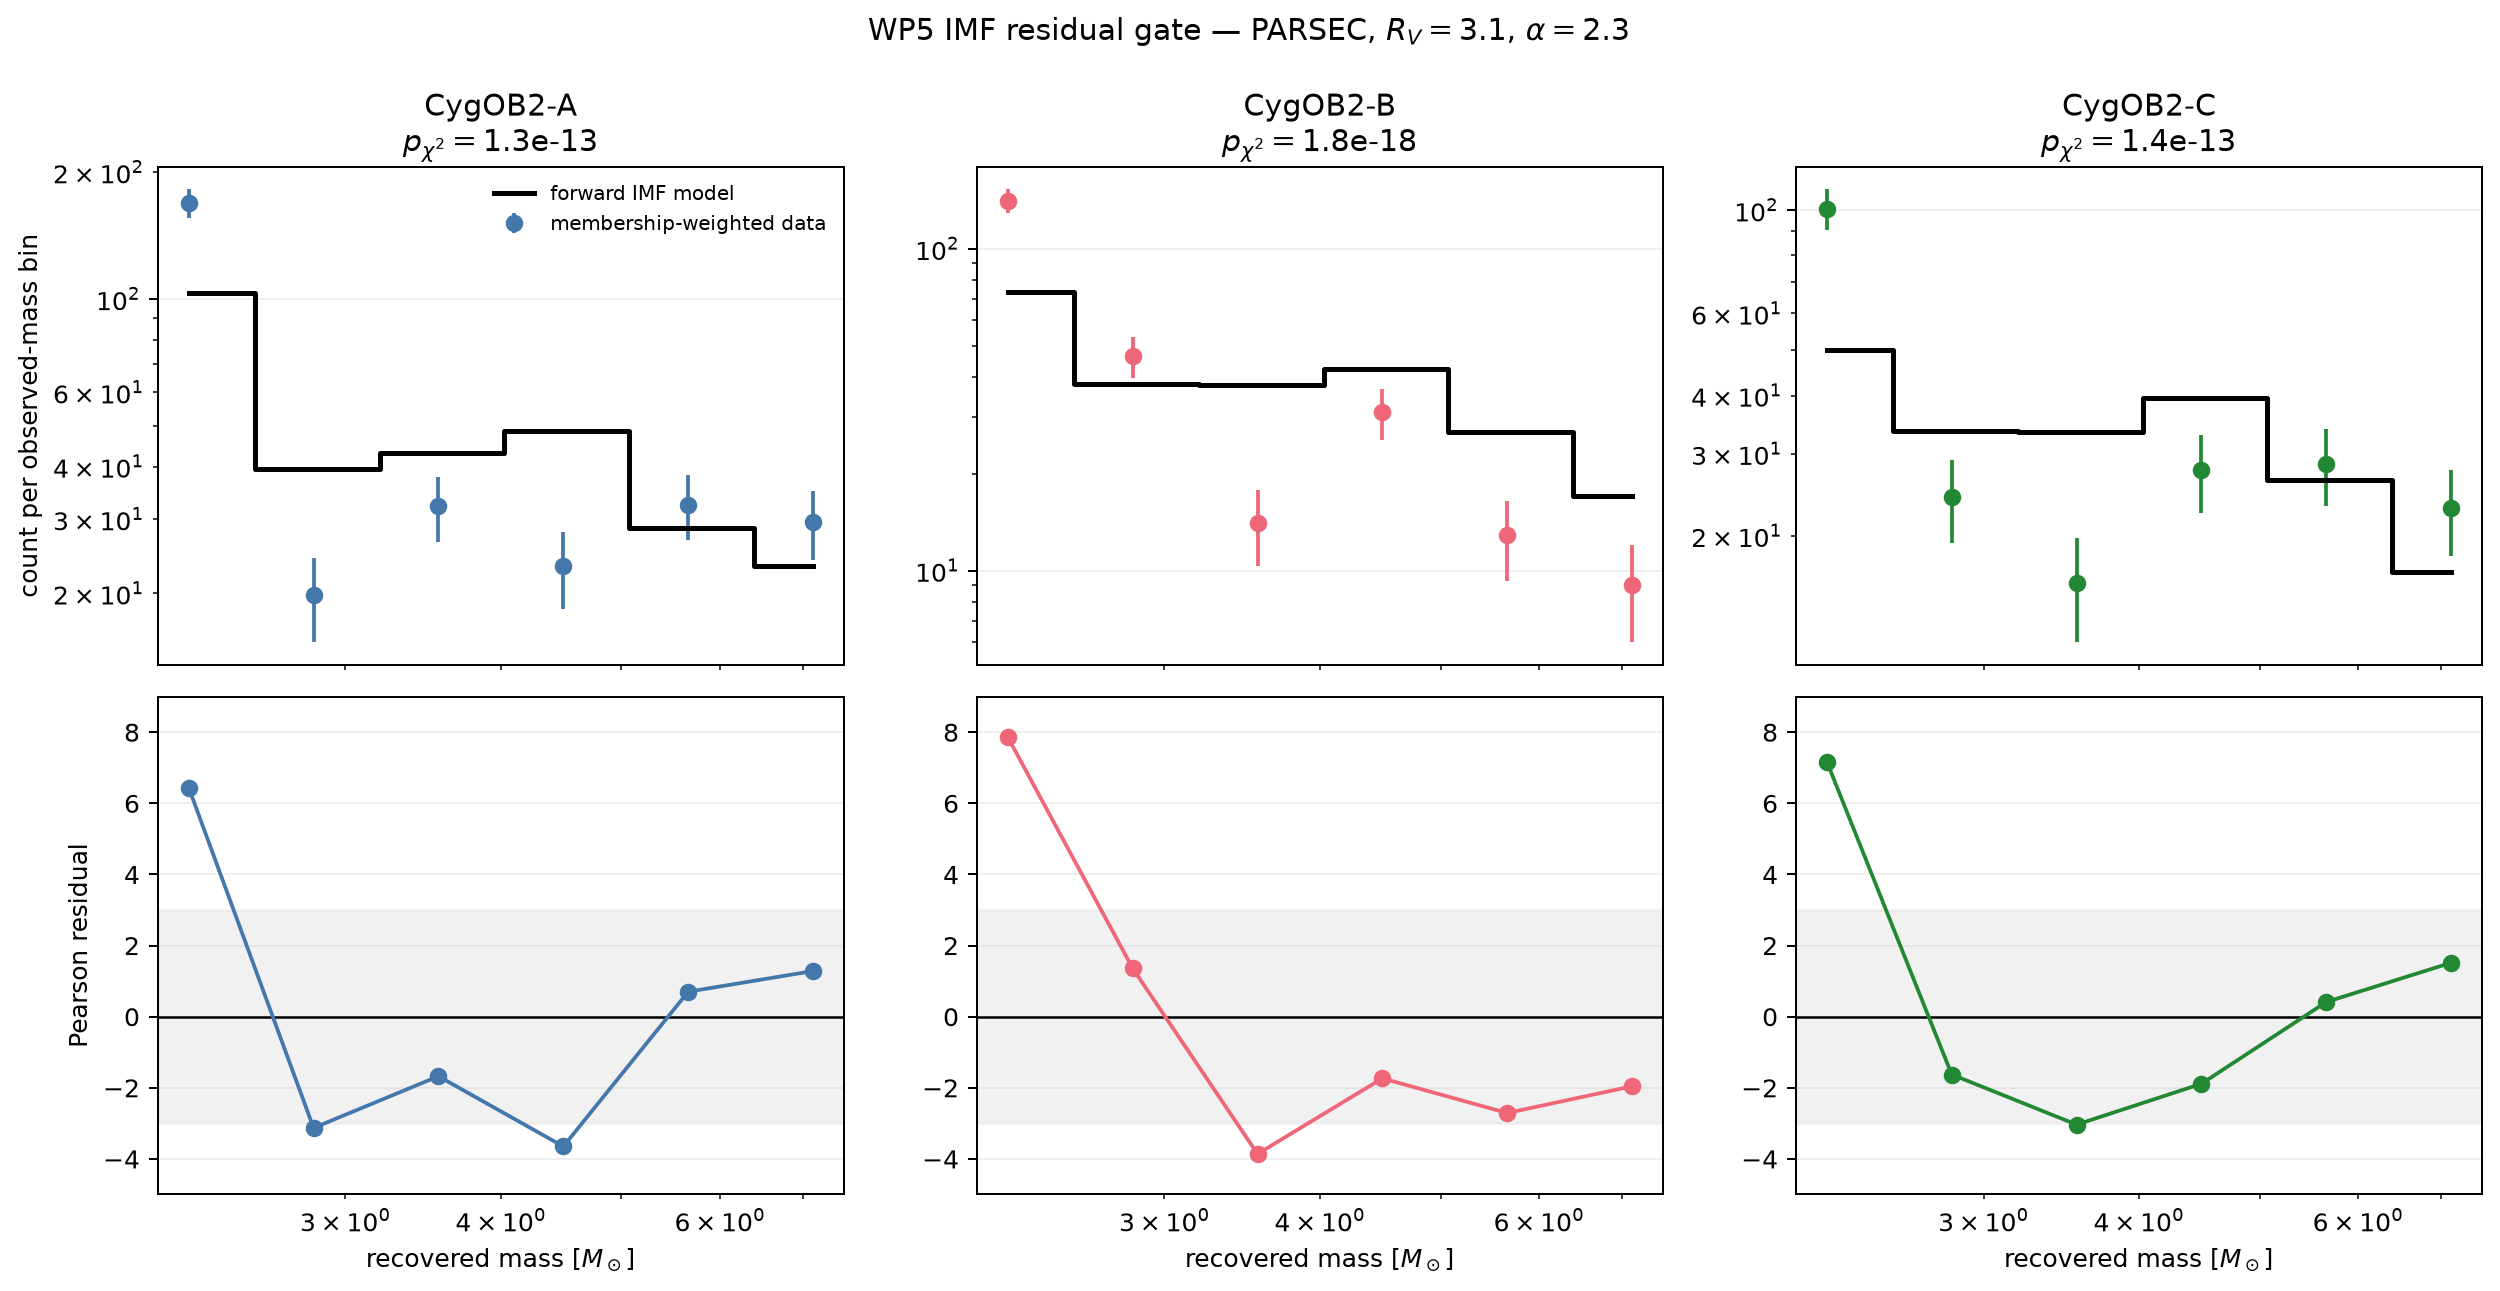

,subgroup,k_median,k_lo68,k_hi68,poisson_chi_square_p,max_abs_pearson_residual,residual_gate_pass
12,CygOB2-A,1531.629307,1441.060772,1625.542617,1.274395e-13,6.442038,False
13,CygOB2-B,1460.226030,1365.043926,1558.806463,1.787496e-18,7.862714,False
14,CygOB2-C,1527.586937,1419.437777,1640.150367,1.424937e-13,7.171090,False


In [4]:
display(Image(filename=str(ROOT / "figures" / "wp5" / "wp5_mass_function.png")))

baseline = normalization[
    (normalization.family == "PARSEC")
    & (normalization.R_V == 3.1)
    & (normalization.alpha == 2.3)
]
baseline[
    ["subgroup", "k_median", "k_lo68", "k_hi68",
     "poisson_chi_square_p", "max_abs_pearson_residual",
     "residual_gate_pass"]
]

## 5. Localize the residual failure

Purpose: show that the failure is not a vague fit-quality label.  In all three
subgroups the recovered 2.0–2.52 M_sun bin is substantially more populated
than the forward response predicts, while adjacent bins are deficient.

Downstream effect: changing only k cannot repair the shape.  The failure
persists through all mandatory IMF slopes, both isochrone families, and all
R_V branches.

In [5]:
baseline_bins = mass_bins[
    (mass_bins.family == "PARSEC")
    & (mass_bins.R_V == 3.1)
    & (mass_bins.alpha == 2.3)
]
first_bin = baseline_bins[baseline_bins.bin_index == 0][
    ["subgroup", "mass_lo", "mass_hi", "membership_weighted_count",
     "expected_count_at_k_median", "pearson_residual"]
]
display(first_bin)

gate_counts = normalization.residual_gate_pass.value_counts(dropna=False)
print("Residual-gate outcomes across all 54 fits:")
display(gate_counts)
assert not normalization.residual_gate_pass.any()

,subgroup,mass_lo,mass_hi,membership_weighted_count,expected_count_at_k_median,pearson_residual
72,CygOB2-A,2.0,2.519842,168.7885,103.310490,6.442038
78,CygOB2-B,2.0,2.519842,140.8467,73.457476,7.862714
84,CygOB2-C,2.0,2.519842,100.6919,49.989807,7.171090


Residual-gate outcomes across all 54 fits:


residual_gate_pass
False    54
Name: count, dtype: int64

## 6. Association-mass sanity check

Purpose: integrate the diagnostic k values over a continuous Kroupa-like IMF
(slope 1.3 below 0.5 M_sun, branch slope above) and add unresolved companions
under f_bin=0.4, q~U[0.1,1].

Interpretation: the baseline mass lies within a factor two of the Wright+15
16,500 M_sun scale.  This is a useful order-of-magnitude check, but it cannot
override a failed mass-function shape: a biased distribution can still have a
plausible integral.

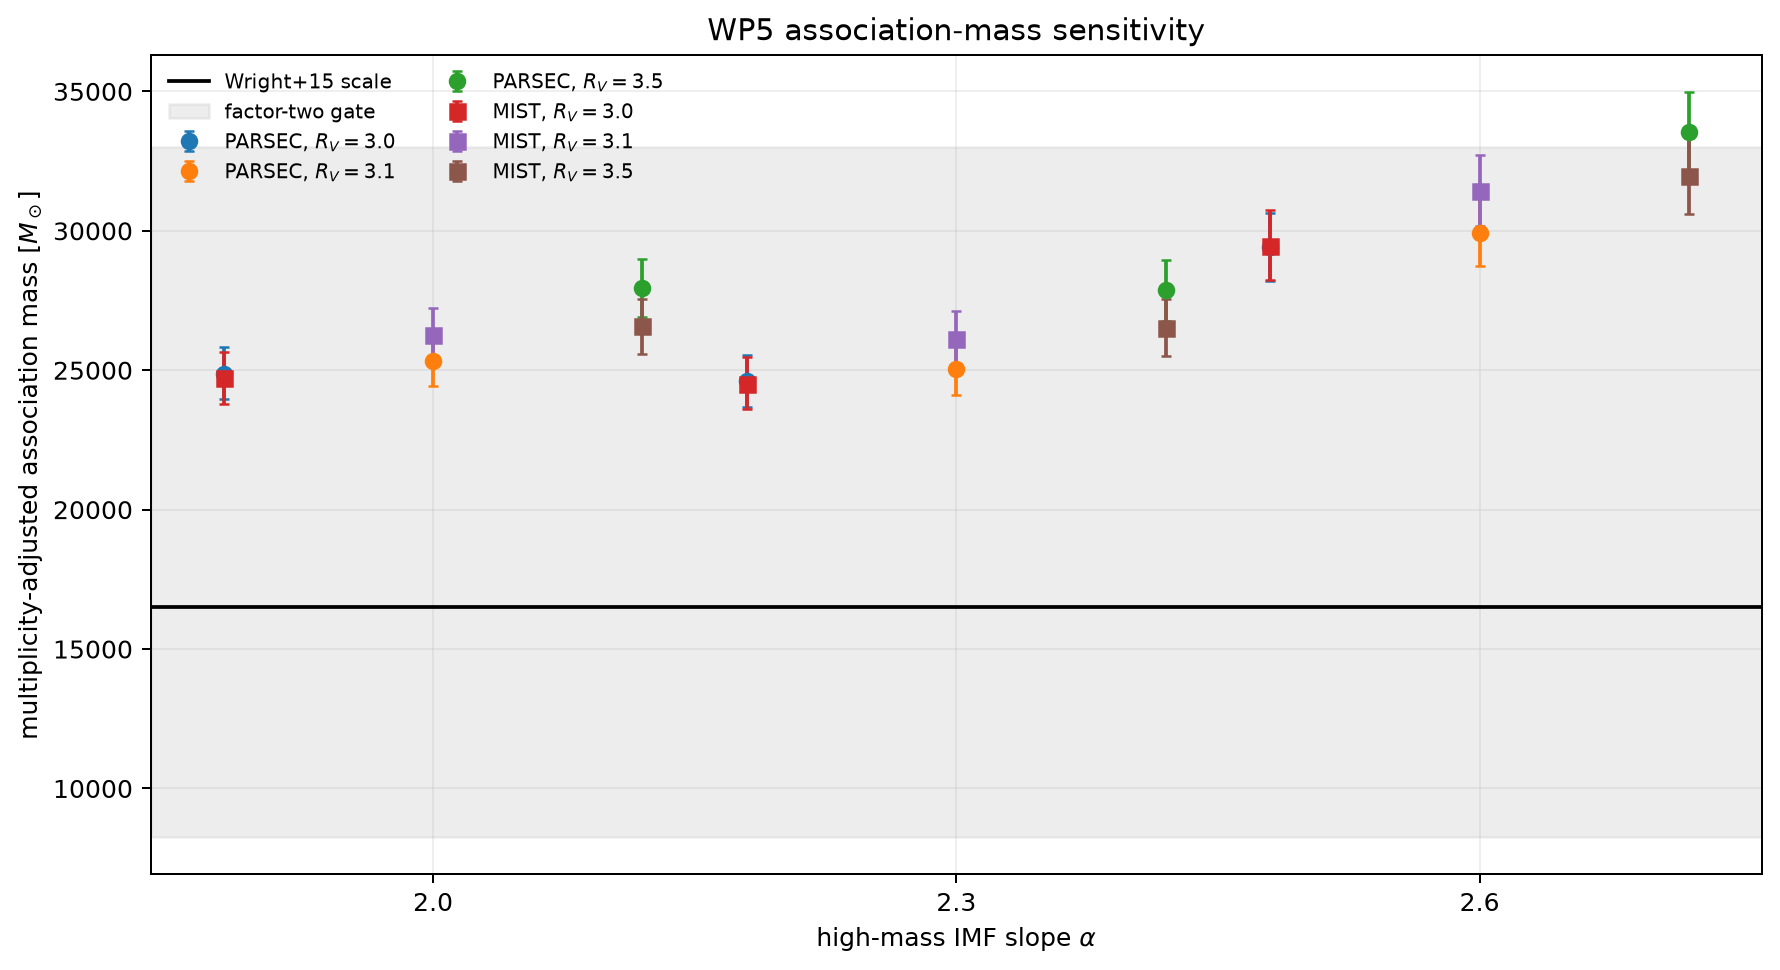

,4
family,PARSEC
R_V,3.1
alpha,2.3
k_total_median,4522.007276
k_total_lo68,4351.872666
k_total_hi68,4698.617407
primary_system_mass_median_Msun,20720.873067
primary_system_mass_lo68_Msun,19941.277317
primary_system_mass_hi68_Msun,21530.141139
multiplicity_adjusted_mass_median_Msun,25049.069376


In [6]:
display(Image(filename=str(ROOT / "figures" / "wp5" / "wp5_association_mass.png")))

baseline_mass = association[
    (association.family == "PARSEC")
    & (association.R_V == 3.1)
    & (association.alpha == 2.3)
]
baseline_mass.T

## 7. Blocking handoff

WP5 is not accepted and WP6/WP7 must not consume the diagnostic normalization.
The evidence calls for a scoped revision of the WP4 2–5 M_sun mass inference:
replace nearest-point masses with per-star mass posteriors or fit the IMF
directly in CMD space, retaining binaries and extinction covariance.  The
current injection catalogue and response machinery should be preserved and
rerun against that revised estimator.

This conclusion is deliberately stronger than “large uncertainty”: the
registered residual gate failed in every branch.

In [7]:
fit_log = json.loads(
    (ROOT / "provenance" / "wp5_imf_fit_execution.json").read_text()
)
gate = pd.Series(fit_log["gate"], name="result")
display(gate)
assert not gate["absolute_95_edge_exists_all_branches"]
assert not gate["baseline_all_subgroups_residual_gate"]
print("FINAL WP5 VERDICT: BLOCKED; no downstream authority.")

absolute_95_edge_exists_all_branches      False
minimum_50_sources_per_subgroup_branch     True
baseline_all_subgroups_residual_gate      False
all_branch_subgroups_residual_gate        False
baseline_mass_within_factor_two            True
all_branch_masses_within_factor_two       False
Name: result, dtype: bool

FINAL WP5 VERDICT: BLOCKED; no downstream authority.
